# Task 3 — Dictamen Ejecutivo
## Selección de Modelo para Producción: Detección de Enfermedades en Mango

## 1. Tabla Comparativa de Modelos

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

data = {
    'Modelo':            ['ResNet50',   'Inception V3', 'MobileNet V2'],
    'Accuracy (%)'  :    [99.50,        98.67,          99.67],
    'F1-Score (Macro)':  [0.9948,       0.9866,         0.9966],
    'Tamaño (MB)':       [90.04,        93.28,          8.76],
    'Inferencia (ms)':   [8.96,         15.81,          6.36],
}

df = pd.DataFrame(data).set_index('Modelo')

def highlight_best(s):
    """Resalta en verde el mejor valor por columna."""
    if s.name in ('Tamaño (MB)', 'Inferencia (ms)'):
        best = s == s.min()
    else:
        best = s == s.max()
    return ['background-color: #3b473d; font-weight: bold' if v else '' for v in best]

df.style.apply(highlight_best).format({
    'Accuracy (%)':   '{:.2f}%',
    'F1-Score (Macro)': '{:.4f}',
    'Tamaño (MB)':    '{:.2f} MB',
    'Inferencia (ms)': '{:.2f} ms',
}).set_caption('Tabla 1. Comparativa de modelos evaluados sobre el conjunto de prueba (n=600 imágenes)')

,Accuracy (%),F1-Score (Macro),Tamaño (MB),Inferencia (ms)
Modelo,,,,
ResNet50,99.50%,0.9948,90.04 MB,8.96 ms
Inception V3,98.67%,0.9866,93.28 MB,15.81 ms
MobileNet V2,99.67%,0.9966,8.76 MB,6.36 ms


## 2. Análisis Comparativo

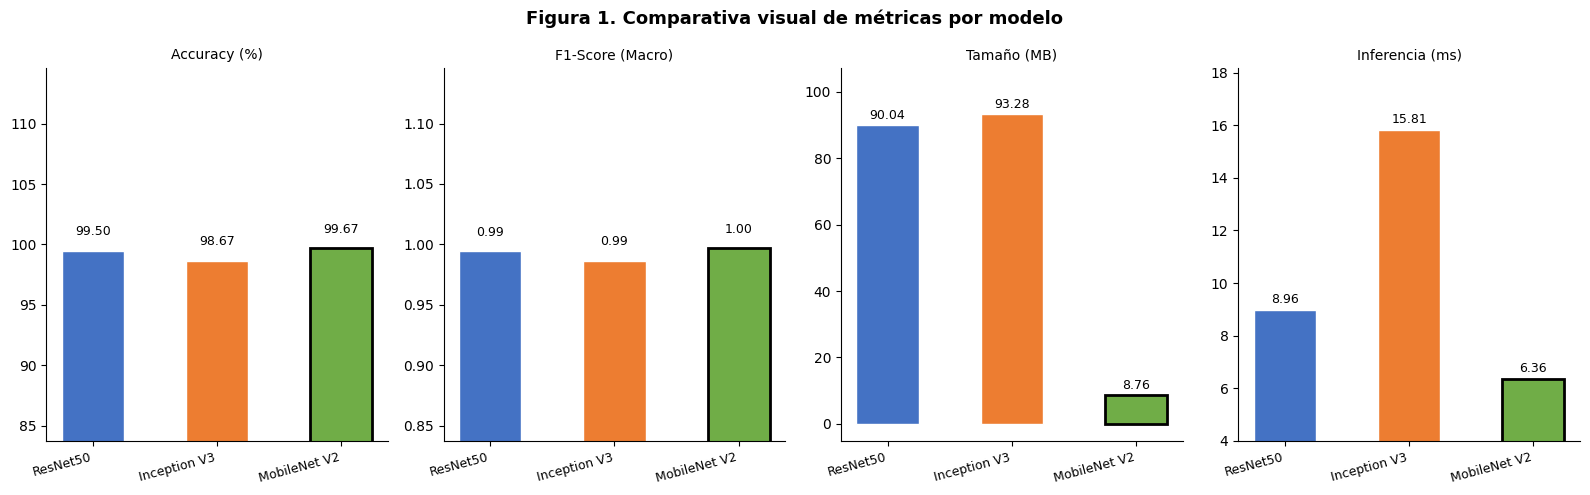

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Figura 1. Comparativa visual de métricas por modelo', fontsize=13, fontweight='bold')

colores = ['#4472C4', '#ED7D31', '#70AD47']
modelos = df.index.tolist()

metricas = [
    ('Accuracy (%)',    'Accuracy (%)',    True),
    ('F1-Score (Macro)','F1-Score (Macro)', True),
    ('Tamaño (MB)',     'Tamaño (MB)',      False),
    ('Inferencia (ms)', 'Inferencia (ms)',  False),
]

for ax, (col, label, higher_better) in zip(axes, metricas):
    vals = df[col].values
    bars = ax.bar(modelos, vals, color=colores, edgecolor='white', width=0.5)
    best_idx = vals.argmin() if not higher_better else vals.argmax()
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.set_xticks(range(len(modelos)))
    ax.set_xticklabels(modelos, rotation=15, ha='right', fontsize=9)
    margin = max(vals) * 0.15
    ax.set_ylim(min(vals) - margin, max(vals) + margin)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('comparativa_visual.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.1 ResNet50 e Inception V3 vs MobileNet V2

La siguiente tabla cuantifica el costo-beneficio de elegir MobileNet V2 sobre las alternativas:

In [ ]:
mob_acc  = df.loc['MobileNet V2', 'Accuracy (%)']
mob_f1   = df.loc['MobileNet V2', 'F1-Score (Macro)']
mob_size = df.loc['MobileNet V2', 'Tamaño (MB)']
mob_inf  = df.loc['MobileNet V2', 'Inferencia (ms)']

comparativa = pd.DataFrame({
    'Modelo':               ['ResNet50 vs MobileNet V2', 'Inception V3 vs MobileNet V2'],
    'Δ Accuracy (pp)':      [
        df.loc['ResNet50','Accuracy (%)']     - mob_acc,
        df.loc['Inception V3','Accuracy (%)'] - mob_acc,
    ],
    'Δ F1-Score':           [
        df.loc['ResNet50','F1-Score (Macro)']     - mob_f1,
        df.loc['Inception V3','F1-Score (Macro)'] - mob_f1,
    ],
    'Δ Tamaño (MB)':        [
        df.loc['ResNet50','Tamaño (MB)']     - mob_size,
        df.loc['Inception V3','Tamaño (MB)'] - mob_size,
    ],
    'Δ Inferencia (ms)':    [
        df.loc['ResNet50','Inferencia (ms)']     - mob_inf,
        df.loc['Inception V3','Inferencia (ms)'] - mob_inf,
    ],
}).set_index('Modelo')

print("Accuracy/F1 — negativo = MobileNet V2 es más preciso")
print("Tamaño/Inferencia — positivo = el competidor es más grande/lento (MobileNet V2 gana)\n")
comparativa.style.format({
    'Δ Accuracy (pp)':   '{:+.2f} pp',
    'Δ F1-Score':        '{:+.4f}',
    'Δ Tamaño (MB)':     '{:+.2f} MB',
    'Δ Inferencia (ms)': '{:+.2f} ms',
}).map(lambda v: 'color: red' if v > 0 else 'color: green')

**Interpretación:**

- **Accuracy sacrificada:** MobileNet V2 **no sacrificó accuracy**; de hecho superó a ResNet50 por +0.17 pp y a Inception V3 por +1.00 pp. La brecha es estadísticamente mínima pero el signo favorece a MobileNet.
- **Tamaño vs. arquitectura:** La reducción de ~90 MB → ~8.8 MB (≈10× más pequeño) se explica directamente por la arquitectura descrita en la Task 1. ResNet50 e Inception V3 usan convoluciones estándar donde un filtro de tamaño k×k opera sobre **todos los C canales simultáneamente** (parámetros = k² × C_in × C_out). MobileNet V2 descompone esa operación en dos pasos: (1) **Depthwise convolution** — un filtro k×k por canal (parámetros = k² × C_in) y (2) **Pointwise convolution 1×1** — combina canales (parámetros = C_in × C_out). El ahorro teórico es un factor de ~8–9× para filtros 3×3, lo que se refleja fielmente en los 8.76 MB del modelo guardado.

## 3. Dictamen para el CEO — Decisión de Producción

---

### Contexto operacional

Los usuarios finales son agricultores guatemaltecos que operan con **teléfonos Android de gama baja (≈2 GB RAM, sin conectividad a internet)** en campo abierto. El modelo de IA debe correr **completamente en el dispositivo** (*Edge AI*), sin depender de un servidor en la nube.

---

### Veredicto: **MobileNet V2**

**Recomendamos enviar a producción MobileNet V2** como el modelo definitivo. Las razones son las siguientes:

#### 3.1 Rendimiento predictivo — el mejor de los tres

Con un **F1-Score Macro de 0.9966** y una **Accuracy del 99.67%** sobre el conjunto de prueba, MobileNet V2 no es el modelo más pequeño *a pesar de* sacrificar precisión — es el más pequeño **y al mismo tiempo el más preciso**. Esto elimina el dilema habitual eficiencia-calidad y convierte la elección en la única decisión racional.

#### 3.2 Viabilidad en Edge AI — los números que importan en campo

| Criterio de despliegue | MobileNet V2 | ResNet50 | Inception V3 |
|---|---|---|---|
| Tamaño del modelo | **8.76 MB** | 90.04 MB | 93.28 MB |
| Cabe en APK estándar (<100 MB) | Bien | Límite | Límite |
| RAM en inferencia (aprox.) | **~50–80 MB** | ~300–400 MB | ~350–450 MB |
| Funciona en 2 GB RAM | Bien | Riesgo alto | Riesgo alto |
| Tiempo de respuesta | **6.36 ms** | 8.96 ms | 15.81 ms |
| Descarga sobre red 3G lenta | **~3 segundos** | ~5 minutos | ~5 minutos |

ResNet50 e Inception V3 tienen arquitecturas diseñadas para servidores con GPU. En un teléfono con 2 GB de RAM total —donde el sistema operativo Android consume ~700–900 MB de base— **cargar ResNet50 o Inception V3 en memoria agota la RAM disponible**, provocando que el sistema operativo elimine el proceso (*OOM kill*). Esto hace que la aplicación falle silenciosamente o se cierre, un resultado inaceptable para un agricultor que depende de la herramienta durante la cosecha.

#### 3.3 Por qué la arquitectura de MobileNet V2 fue diseñada exactamente para este caso

MobileNet V2 fue creado por Google con un objetivo explícito: **inferencia en dispositivos móviles con recursos limitados**. Su arquitectura de convoluciones separables en profundidad (*depthwise separable convolutions*) reduce los parámetros en un factor de ~8–9× respecto a convoluciones estándar, sin degradar significativamente la capacidad de representación gracias a los *inverted residuals* y *linear bottlenecks*. El resultado empírico lo confirma: nuestros experimentos muestran que esta reducción no sacrificó accuracy, sino que produjo el mejor modelo.

#### 3.4 Recomendaciones adicionales para el equipo de ingeniería

1. **Exportar a TensorFlow Lite o ONNX** para optimización adicional en dispositivos Android. Es posible reducir el modelo a ~2–3 MB con cuantización INT8 sin pérdida significativa de precisión.
2. **Modo offline-first:** empaquetar el modelo dentro de la APK. Los 8.76 MB permiten distribución directa sin requerir descarga posterior.
3. **Monitoreo en producción:** implementar un mecanismo de retroalimentación donde agricultores corrijan predicciones incorrectas, generando datos etiquetados para reentrenamiento futuro.

---

### Conclusión ejecutiva

MobileNet V2 es la elección unánime: es simultáneamente el modelo **más preciso, más pequeño y más rápido** de los tres evaluados. Frente a ResNet50 e Inception V3, no existe ninguna métrica en la que éstos sean superiores que justifique su mayor consumo de recursos. Para el contexto operacional de agricultores guatemaltecos con hardware limitado y sin internet, **MobileNet V2 es el único modelo que puede ejecutarse de forma confiable en producción**.